In [192]:
import pandas as pd
import numpy as np
import pickle, os
from matplotlib import pyplot as plt
from tqdm import tqdm


In [193]:
import pandas as pd

omegas_file = '/Volumes/LaCie/STEPs/ConvergenceTest/walkers2/1/output.txt'

# Step 1: Read the column names from the line starting with "#! FIELDS"
with open(omegas_file, 'r') as f:
    for line in f:
        if line.startswith('#! FIELDS'):
            columns = line.strip().split()[2:]  # Skip '#!', 'FIELDS'
            break

# Step 2: Use `pd.read_csv` with `skiprows`
def skip_every_20th(start, total_lines):
    # Skip header line, then the rest
    return [i for i in range(start, total_lines) if i % 20 != 0]

with open(omegas_file, 'r') as f:
    # Count total lines minus comment lines
    total_rows = sum(1 for line in f if not line.startswith('#'))

# Now, use `skiprows` to skip rows directly in pandas, excluding indices for FIELDS and comments
df = pd.read_csv(
    omegas_file,
    delim_whitespace=True,
    comment='#',
    header=None,
    names=columns,
    skiprows=skip_every_20th(1, total_rows)  # Start after '#! FIELDS' line
)

# Display the DataFrame
df

,time,omega1,omega2,omega3,psi1,psi2,psi3,psi4,phi1,phi2,...,chi1,chi2,chi3,chi4,chi5,chi6,chi7,chi8,chi9,pb.bias
0,0.1,0.119384,-0.306472,0.240992,-3.079229,-2.722657,2.631261,-1.664859,0.126267,-0.487410,...,-3.092020,-2.905644,0.751169,-2.148068,-2.864282,-1.935212,1.553715,-1.379129,-3.053131,0.000000
1,2.1,0.500100,0.290813,0.025368,3.059580,2.887299,-3.040839,0.655888,0.717475,0.394476,...,-1.092128,2.143073,1.055995,-1.387877,-2.713999,-1.495562,2.715728,1.243423,0.195185,0.455391
2,4.1,0.475823,0.156696,0.276742,2.676110,3.002649,3.085210,0.170564,0.199451,-0.183012,...,-2.339996,2.802122,1.217886,-1.501741,-2.942674,-1.217448,3.019142,0.898901,0.548432,0.755896
3,6.1,0.402649,0.053453,-0.062878,3.123282,1.738001,3.055424,0.323349,0.253448,0.603216,...,-1.544421,3.045864,1.871312,-1.528110,-3.065812,-1.530217,-3.029280,1.747154,-0.543873,1.147002
4,8.1,0.579734,0.122588,0.130728,3.031403,1.249111,3.131536,0.311464,0.398073,0.590163,...,-1.115628,-3.121512,0.980258,-1.810573,2.999994,-1.132511,2.702114,1.771882,-1.050719,1.942832
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
207771,415475.9,2.881563,-3.027529,-2.864124,-2.864625,2.583286,-2.776185,-2.835748,2.922816,-2.878552,...,1.148143,-2.387011,1.116206,-1.723276,1.347877,-1.745910,0.844188,1.364827,2.461860,231.353798
207772,415476.0,3.009342,3.136772,-2.913429,-3.030784,2.527905,-2.750361,-2.942938,2.972247,-2.836437,...,1.531859,-2.415560,1.043402,-1.869004,1.170388,-1.683957,0.906389,1.275623,2.619516,231.745435
207773,415476.1,-3.108244,3.125165,-2.911672,-2.874416,2.500864,-2.976435,-2.630301,3.080083,-2.951546,...,1.534155,-2.501527,0.948829,-1.845173,1.142739,-1.755167,0.960443,1.259743,2.501689,231.710462
207774,415476.2,-3.020737,-2.925904,-2.963375,-2.971035,2.610033,-2.839024,-2.869699,2.913692,-3.032263,...,1.390004,-2.151688,1.420208,-1.817927,0.898637,-1.934624,0.895366,1.540525,2.439955,231.320621


In [194]:
# Extract the omegas 
omega_df = df[['omega1', 'omega2', 'omega3']]
# omega_df.astype(float)
omega_np = omega_df.to_numpy()
omega_np.shape
# Convert the radians to angles
omega_angle = omega_np * (180 / np.pi)

In [195]:
class Data:
    def __init__(self, array_list):
        self.array_list = array_list

    def save(self, filename):
        with open(filename, 'wb') as f:
            pickle.dump(self.array_list, f)

    @classmethod
    def load(cls, filename):
        with open(filename, 'rb') as f:
            array_list = pickle.load(f)
        return cls(array_list)

<ipython-input-196-27f600e2b33f>:19: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  plt.tight_layout()


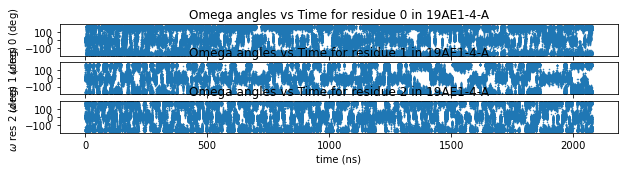

In [196]:
def omega2cistrans(omega):
    """Converts a sequence of float omega angles (in degrees) to an array of ints: 0 cis and 1 trans."""
    
    shifted_omega = (omega + 90.0) % 360.0 - 90.0 # shift into (-90, 270) range to avoid periodic boundaries
    
    cistrans = np.where(shifted_omega > 90.0, 1, 0).astype(int)
    return cistrans
## Plot omega angles vs time for selected residues for each replica
residues_to_plot = [0, 1, 2]

plt.figure(figsize=(10, 2))
for panel, residue in enumerate(residues_to_plot, 1):
    plt.subplot(len(residues_to_plot), 1, panel)
    t = np.arange(omega_angle.shape[0]) * 0.010  # Time axis in ns
    plt.plot(t, omega_angle[:, residue], '.', ms=1)
    plt.xlabel('time (ns)')
    plt.ylabel(f'$\\omega$ res {residue} (deg)')
    plt.title(f'Omega angles vs Time for residue {residue} in 19AE1-4-A')
plt.tight_layout()
## Save the data 


In [197]:
all_cistrans = omega2cistrans(omega_angle)
all_cistrans.shape

(207776, 3)

In [198]:
os.makedirs('ct_data_8o', exist_ok=True )
data_instance = Data(omega_angle)
data_instance.save("ct_data_8o/all_omega0.pkl")

In [199]:
sanity_df = df[['time','omega1', 'omega2', 'omega3']]
sanity_df.to_csv("ct_data_8o/timeomega0.dat", sep=' ')

In [200]:
sanity_df

,time,omega1,omega2,omega3
0,0.1,0.119384,-0.306472,0.240992
1,2.1,0.500100,0.290813,0.025368
2,4.1,0.475823,0.156696,0.276742
3,6.1,0.402649,0.053453,-0.062878
4,8.1,0.579734,0.122588,0.130728
...,...,...,...,...
207771,415475.9,2.881563,-3.027529,-2.864124
207772,415476.0,3.009342,3.136772,-2.913429
207773,415476.1,-3.108244,3.125165,-2.911672
207774,415476.2,-3.020737,-2.925904,-2.963375


In [201]:
### PRINTS STATE ESTIMATES BASED ON PBMETAD BIAS POPULATION AS A FRACTION AND dG Values ####
object_columns = df.select_dtypes(include=['object']).columns

# Convert all object columns to float, non-convertible values will be NaN
df[object_columns] = df[object_columns].apply(pd.to_numeric, errors='coerce')

df['om1']=df['omega1']*(180/np.pi)
df['om2']=df['omega2']*(180/np.pi)
df['om3']=df['omega3']*(180/np.pi)


conditions = [
    ((df['om1'] >=-45) & (df['om1'] <=45)) & ((df['om2'] >=-45) & (df['om2'] <=45)) & ((df['om3'] >=-45) & (df['om3'] <=45)),
    ((df['om1'] >=-45) & (df['om1'] <=45)) & ((df['om2'] >=-45) & (df['om2'] <=45)) & ((df['om3'] <=-135) | (df['om3'] >=135)),
    ((df['om1'] >=-45) & (df['om1'] <=45)) & ((df['om2'] <=-135) | (df['om2'] >=135)) & ((df['om3'] >=-45) & (df['om3'] <=45)),
    ((df['om1'] <=-135) | (df['om1'] >=135)) & ((df['om2'] >=-45) & (df['om2'] <=45)) & ((df['om3'] >=-45) & (df['om3'] <=45)),
    
    ((df['om1'] <=-135) | (df['om1'] >=135)) & ((df['om2'] <=-135) | (df['om2'] >=135)) & ((df['om3'] >=-45) & (df['om3'] <=45)),
    ((df['om1'] <=-135) | (df['om1'] >=135)) & ((df['om2'] >=-45) & (df['om2'] <=45)) & ((df['om3'] <=-135) | (df['om3'] >=135)),
    ((df['om1'] >=-45) & (df['om1'] <=45)) & ((df['om2'] <=-135) | (df['om2'] >=135)) & ((df['om3'] <=-135) | (df['om3'] >=135)),
    ((df['om1'] <=-135) | (df['om1'] >=135)) & ((df['om2'] <=-135) | (df['om2'] >=135)) & ((df['om3'] <=-135) | (df['om3'] >=135))
]
choices = [1,2,3,4,5,6,7,8]
# conditions = [
#     ((df['phi'] <= 130) & (df['phi'] >= 70)) & ((df['psi'] >= 110) & (df['psi'] <=260)) & ((df['omega'] >=-45) & (df['omega'] <=45)),
#     ((df['phi'] >= 230) & (df['phi'] <= 290)) & ((df['psi'] >= 110) & (df['psi'] <=230)) & ((df['omega'] >=-45) & (df['omega'] <=45)),
#     ((df['phi'] <= 160) & (df['phi'] >= 110)) & ((df['psi'] >= 280) & (df['psi'] <= 340)) & ((df['omega'] >=-45) & (df['omega'] <=45)),
#     ((df['phi'] <= 260) & (df['phi'] >= 220)) & ((df['psi'] <= 80) & (df['psi'] >= 20)) & ((df['omega'] >=-45) & (df['omega'] <=45)),
#     ((df['phi'] <= 130) & (df['phi'] >= 20)) & ((df['psi'] <= 80) & (df['psi'] >= 20)) & ((df['omega'] >=-45) & (df['omega'] <=45)),
#     ((df['phi'] <= 340) & (df['phi'] >= 220)) & ((df['psi'] <= 340) & (df['psi'] >= 280)) & ((df['omega'] >=-45) & (df['omega'] <=45)),
    
#     ((df['phi'] <= 130) & (df['phi'] >= 70)) & ((df['psi'] >= 110) & (df['psi'] <=260)) & ((df['omega'] <=-135) | (df['omega'] >=135)),
#     ((df['phi'] >= 190) & (df['phi'] <= 290)) & ((df['psi'] >= 110) & (df['psi'] <=230)) & ((df['omega'] <=-135) | (df['omega'] >=135)),
#     ((df['phi'] <= 160) & (df['phi'] >= 110)) & ((df['psi'] >= 280) & (df['psi'] <= 320)) & ((df['omega'] <=-135) | (df['omega'] >=135)),
#     ((df['phi'] <= 260) & (df['phi'] >= 220)) & ((df['psi'] <= 80) & (df['psi'] >= 20)) & ((df['omega'] <=-135) | (df['omega'] >=135)),
#     ((df['phi'] <= 130) & (df['phi'] >= 20)) & ((df['psi'] <= 80) & (df['psi'] >= 20)) & ((df['omega'] <=-135) | (df['omega'] >=135)),
#     ((df['phi'] <= 340) & (df['phi'] >= 220)) & ((df['psi'] <= 340) & (df['psi'] >= 280)) & ((df['omega'] <=-135) | (df['omega'] >=135)),
# ]

# choices = [2, 5, 3, 4, 1, 6, 8, 11, 9, 10, 7, 12]
df['c'] = np.select(conditions, choices, default=0)
# sns.scatterplot(df['c'])
# # sns.scatterplot(x=df['phi'].loc[df['c']<0],y=df['psi'].loc[df['c']<0])
# plt.show()

# fig2, ax2 = plt.subplots()
# ax2.set_aspect('equal')
# sns.scatterplot(x=df['phi'].loc[df['c']<=6],y=df['psi'].loc[df['c']<=6],color='black')
# # sns.scatterplot(x=df['phi'].loc[df['c']==0],y=df['psi'].loc[df['c']==0],color='grey')

# # plt.show()
# ax2.set_xticks(np.arange(-1,361,45))
# ax2.set_yticks(np.arange(-1,361,45))
# ax2.set_title('cis', fontsize=12, fontweight='bold')
# ax2.set_xlabel('$\Phi$ Dihedral angle($\circ$)', fontsize=12, fontweight='bold')
# ax2.set_ylabel('$\Psi\'$ Dihedral angle($\circ$)', fontsize=12, fontweight='bold')
# plt.show()
# fig2, ax2 = plt.subplots()
# ax2.set_aspect('equal')
# sns.scatterplot(x=df['phi'].loc[df['c']>6],y=df['psi'].loc[df['c']>6],color='black')
# # sns.scatterplot(x=df['phi'].loc[df['c']==0],y=df['psi'].loc[df['c']==0],color='grey')
# ax2.set_title('trans', fontsize=12, fontweight='bold')
# ax2.set_xticks(np.arange(-1,361,45))
# ax2.set_yticks(np.arange(-1,361,45))
# ax2.set_xlabel('$\Phi$ Dihedral angle($\circ$)', fontsize=12, fontweight='bold')
# ax2.set_ylabel('$\Psi\'$ Dihedral angle($\circ$)', fontsize=12, fontweight='bold')
# plt.show()

global_min=np.exp(df['pb.bias']/2.5).sum()
# print(global_min)
for val in range(0,8,1):
    print("state:",val,"P:",(np.exp(df['pb.bias'].loc[df['c']==val]/2.5).sum())/global_min,"dG=-ktln(P):",-0.6*np.log(np.exp(df['pb.bias'].loc[df['c']==val]/2.5).sum()/global_min))

# print((np.exp(df['bias'].loc[(df['c']<=6) & (df['c']>0)]/2.5).sum())/global_min)
# print((np.exp(df['bias'].loc[(df['c']>6)]/2.5).sum())/global_min)

state: 0 P: 0.009169372241509625 dG=-ktln(P): 2.81513187174465
state: 1 P: 0.07238867703372581 dG=-ktln(P): 1.5754232318299015
state: 2 P: 0.12744386554179926 dG=-ktln(P): 1.2360475689548769
state: 3 P: 0.0760004117481205 dG=-ktln(P): 1.5462099125832325
state: 4 P: 0.08254410465097271 dG=-ktln(P): 1.4966535159961072
state: 5 P: 0.14177749417807148 dG=-ktln(P): 1.172097835636218
state: 6 P: 0.19167243918267649 dG=-ktln(P): 0.9911804458989506
state: 7 P: 0.03983394416391219 dG=-ktln(P): 1.9338215170424233
